In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt
from pylab import meshgrid
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy import optimize
from scipy.integrate import quad
import pandas as pd

In [2]:
from scaledOptim_coreFunc import*

In [3]:
neon_data = pd.read_csv("./Data/NEON_full.csv")
global_data = pd.read_csv("./Data/global_full.csv")

In [4]:
var_list = ['plotID', 'latitude', 'CHELSA_gsl_1981.2010_V.2.1', 'CHELSA_fgd_1981.2010_V.2.1',
           'CHELSA_gsp_1981.2010_V.2.1', 'CHELSA_gst_1981.2010_V.2.1', 'gshurs', 'gs_sfcWind', 
           'wc2.1_30s_elev', 'gedi_rh90_1000m', 'mean', 'n', 'gsPARdif', 
           'gsPARdir', 'gsSWdiff', 'gsSWdir']
mod_data = neon_data[var_list]
mod_data.fillna({'CHELSA_fgd_1981.2010_V.2.1': 0}, inplace=True)
mod_data.dropna(inplace=True)


In [5]:
mod_data_f = mod_data[mod_data['CHELSA_gsl_1981.2010_V.2.1'] < 280]
len(mod_data_f), len(mod_data)

(72, 285)

In [6]:
mod_data_f

,plotID,latitude,CHELSA_gsl_1981.2010_V.2.1,CHELSA_fgd_1981.2010_V.2.1,CHELSA_gsp_1981.2010_V.2.1,CHELSA_gst_1981.2010_V.2.1,gshurs,gs_sfcWind,wc2.1_30s_elev,gedi_rh90_1000m,mean,n,gsPARdif,gsPARdir,gsSWdiff,gsSWdir
95,HARV_040,42.539927,216,121.0,783.9,14.35,60.887143,2.605000,373,15.453125,0.010589,200.0,53.295066,38.663594,104.310170,97.201035
96,HARV_036,42.542132,213,123.0,796.9,14.35,61.048571,2.883714,390,15.453125,0.008856,200.0,53.295066,38.663594,104.310170,97.201035
97,HARV_042,42.534180,216,121.0,783.9,14.35,60.887143,2.605000,373,13.390625,0.014646,200.0,53.295066,38.663594,104.310170,97.201035
98,HARV_047,42.536689,216,121.0,783.9,14.35,60.887143,2.605000,373,15.453125,0.009166,200.0,53.295066,38.663594,104.310170,97.201035
99,HARV_045,42.542085,213,123.0,796.9,14.35,61.048571,2.883714,390,15.453125,0.010180,200.0,53.295066,38.663594,104.310170,97.201035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,UNDE_057,46.234300,184,128.0,573.7,13.55,59.470000,3.134000,517,21.375000,0.010194,200.0,54.410627,43.528231,107.432125,107.635063
325,UNDE_058,46.231090,185,127.0,567.7,13.45,59.461667,3.317667,520,21.375000,0.005392,200.0,54.410627,43.528231,107.432125,107.635063
326,UNDE_059,46.230685,186,126.0,567.9,13.55,59.518333,3.252667,510,14.546875,0.005181,200.0,54.410627,43.528231,107.432125,107.635063
327,UNDE_060,46.231420,185,127.0,567.7,13.45,59.461667,3.317667,520,21.375000,0.014692,200.0,54.410627,43.528231,107.432125,107.635063


In [7]:
G_vect = np.vectorize(G_de, otypes=[list])

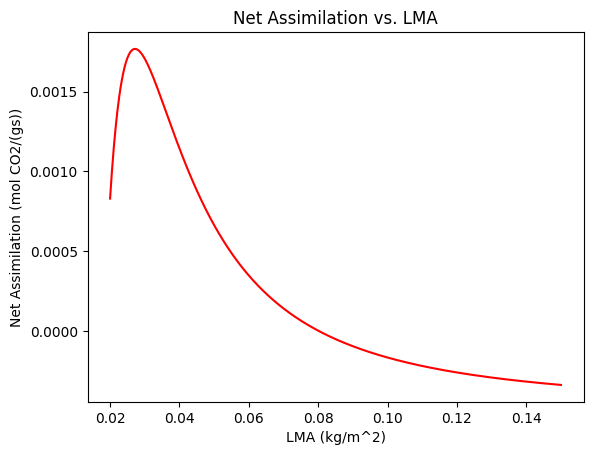

In [40]:
row = mod_data_f.iloc[1]
h = row['gedi_rh90_1000m']
lat = np.radians(row['latitude'])
gsDay_s = int(row['CHELSA_fgd_1981.2010_V.2.1'])
gsDay_e = int(row['CHELSA_gsl_1981.2010_V.2.1'] + row['CHELSA_fgd_1981.2010_V.2.1'])
sfcWind = row['gs_sfcWind']
hurs = row['gshurs']
temp = row['CHELSA_gst_1981.2010_V.2.1']
precip = row['CHELSA_gsp_1981.2010_V.2.1']/1000
eLMA = row['mean']
elev = row['wc2.1_30s_elev']
Rdir = row['gsSWdir']
Rdif = row['gsSWdiff']
RPARdir = row['gsPARdir']
RPARdif = row['gsPARdif']
    
x = np.linspace(0.02, 0.15, 1000)
y =  [G_de(LMA=i, h=0.25, x_can=1, a_l=0.001, p_inc=precip, T_A=temp, uw=sfcWind, RH=hurs, lat=lat, alt=elev, R_dir=0.25*Rdir, R_dif=0.25*Rdif, R_PAR_dir=0.25*RPARdir, R_PAR_dif=0.25*RPARdif, gsday_s=gsDay_s, gsday_e=gsDay_e) for i in x]

plot = plt.plot(x, y, color='red')

plt.title('Net Assimilation vs. LMA')
plt.xlabel('LMA (kg/m^2)')
plt.ylabel('Net Assimilation (mol CO2/(gs))')

plt.show(plot)

In [28]:
G_de(LMA=0.04, h=h, x_can=1, a_l=0.001, p_inc=precip, T_A=temp, uw=sfcWind, RH=hurs, lat=lat, alt=elev, R_dir=Rdir, R_dif=Rdif, R_PAR_dir=RPARdir, R_PAR_dif=RPARdif, gsday_s=gsDay_s, gsday_e=gsDay_e)

array([5.36677179])

In [8]:
varNames = ['plotID', 'LMA_max']
maxima = pd.DataFrame(columns=varNames)
for idx, row in mod_data_f.iterrows():
        h = row['gedi_rh90_1000m']
        lat = np.radians(row['latitude'])
        gsDay_s = int(row['CHELSA_fgd_1981.2010_V.2.1'])
        gsDay_e = int(row['CHELSA_gsl_1981.2010_V.2.1'] + row['CHELSA_fgd_1981.2010_V.2.1'])
        sfcWind = row['gs_sfcWind']
        hurs = row['gshurs']
        temp = row['CHELSA_gst_1981.2010_V.2.1']
        precip = row['CHELSA_gsp_1981.2010_V.2.1']/1000
        eLMA = row['mean']
        elev = row['wc2.1_30s_elev']
        Rdir = row['gsSWdir']
        Rdif = row['gsSWdiff']
        RPARdir = row['gsPARdir']
        RPARdif = row['gsPARdif']
        plotID = row['plotID']

        f = lambda x: -G_de(LMA=x, h=h, x_can=1, a_l=0.001, p_inc=precip, T_A=temp, uw=sfcWind, RH=hurs, lat=lat, alt=elev, R_dir=Rdir, R_dif=Rdif, R_PAR_dir=RPARdir, R_PAR_dif=RPARdif, gsday_s=gsDay_s, gsday_e=gsDay_e).item(0)

        LMA_max = optimize.minimize(f, eLMA, method='Nelder-Mead').x[0]
    
        maxima.loc[idx] = (plotID, LMA_max)
        print(plotID, eLMA, LMA_max, h)
    



c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt

HARV_040 0.010588744 0.04142846089999999 15.453125
HARV_036 0.008856226 0.041513559375000036 15.453125
HARV_042 0.014645514 0.03986325841875 13.390625
HARV_047 0.009165972 0.04141873597500001 15.453125
HARV_045 0.01018009075 0.041547495373437576 15.453125
HARV_037 0.011748092 0.04475288796250006 20.46875
HARV_033 0.01479148025 0.04141614470000005 15.453125
HARV_038 0.0150147085 0.04476259971562515 20.46875
HARV_039 0.01642738875 0.04414860726562493 19.484375
HARV_034 0.02686856425 0.04475295232890629 20.46875
HARV_035 0.01067011175 0.044747781151562485 20.46875
HARV_043 0.01143224375 0.04144188359374997 15.453125
HARV_044 0.010950208 0.041405474 15.453125
HARV_041 0.0127153655 0.04474219235312493 20.46875
HARV_052 0.010965819 0.04153303946249997 15.453125
HARV_048 0.0118994815 0.04477179914375005 20.46875
HARV_050 0.01133568925 0.04477597253750005 20.46875
HARV_049 0.01172297275 0.044730467899218834 20.46875
HARV_046 0.010815975 0.04475109656250005 20.46875
HARV_051 0.010071719 0.04412

c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt

In [9]:
maxima.to_csv('NEON_pred.csv', index = False)

In [11]:
var_list = ['Plot', 'Latitude', 'CHELSA_gsl_1981.2010_V.2.1', 'CHELSA_fgd_1981.2010_V.2.1',
           'CHELSA_gsp_1981.2010_V.2.1', 'CHELSA_gst_1981.2010_V.2.1', 'gshurs', 'gs_sfcWind', 
           'wc2.1_30s_elev', 'gedi_rh90_1000m', 'mean', 'n', 'gsPARdif', 
           'gsPARdir', 'gsSWdiff', 'gsSWdir']
mod_data = global_data[var_list]
mod_data.fillna({'CHELSA_fgd_1981.2010_V.2.1': 0}, inplace=True)
mod_data.dropna(inplace=True)


In [12]:
mod_data_f = mod_data[mod_data['CHELSA_gsl_1981.2010_V.2.1'] < 280]
len(mod_data_f), len(mod_data)

(19, 56)

In [14]:
mod_data_f

,Plot,Latitude,CHELSA_gsl_1981.2010_V.2.1,CHELSA_fgd_1981.2010_V.2.1,CHELSA_gsp_1981.2010_V.2.1,CHELSA_gst_1981.2010_V.2.1,gshurs,gs_sfcWind,wc2.1_30s_elev,gedi_rh90_1000m,mean,n,gsPARdif,gsPARdir,gsSWdiff,gsSWdir
14,LAPENA,23.627700,211,6.0,689.5,10.95,53.911429,2.608143,2837.0,9.148438,0.027480,200.0,30.209778,30.497519,73.535139,97.558618
15,MIQUIHUANA,23.578500,133,6.0,548.8,15.15,55.445000,3.121500,2204.0,5.917969,0.079425,200.0,5.850988,11.974059,35.979395,67.296196
17,AlmontCO,38.699536,148,154.0,272.5,10.95,48.858000,1.832200,2598.0,10.750000,0.021674,200.0,58.104339,60.621790,118.684212,147.614919
20,LSV,32.446810,183,85.0,385.7,11.85,43.573333,2.826833,2614.0,27.062500,0.018225,200.0,45.309110,88.259527,87.264228,213.022756
22,SNP1,36.721940,255,39.0,972.3,8.25,48.208750,1.212250,1886.0,27.078125,0.088828,200.0,42.443449,66.674653,86.075553,165.358800
25,SNP4,36.478060,59,248.0,97.9,6.55,43.545000,1.450500,2785.0,18.484375,0.025325,200.0,40.240765,81.699802,78.402996,201.821251
26,SNP5,36.632000,148,167.0,269.6,11.65,44.616000,1.258200,2135.0,32.812500,0.089886,200.0,46.298779,87.497925,91.631113,215.849698
30,SkiValley,32.443194,183,85.0,385.7,11.85,43.573333,2.826833,2614.0,17.375000,0.056149,200.0,45.309110,88.259527,87.264228,213.022756
32,WG-4,38.963872,82,204.0,278.6,8.35,48.733333,3.156667,3330.0,2.199219,0.028112,200.0,52.714184,64.029813,104.086767,154.776138
46,HFRT2,42.540536,216,121.0,783.9,14.35,60.887143,2.605000,373.0,20.468750,0.012784,200.0,53.295066,38.663594,104.310170,97.201035


In [13]:
varNames = ['plotID', 'LMA_max']
maxima = pd.DataFrame(columns=varNames)
for idx, row in mod_data_f.iterrows():
        h = row['gedi_rh90_1000m']
        lat = np.radians(row['Latitude'])
        gsDay_s = int(row['CHELSA_fgd_1981.2010_V.2.1'])
        gsDay_e = int(row['CHELSA_gsl_1981.2010_V.2.1'] + row['CHELSA_fgd_1981.2010_V.2.1'])
        sfcWind = row['gs_sfcWind']
        hurs = row['gshurs']
        temp = row['CHELSA_gst_1981.2010_V.2.1']
        precip = row['CHELSA_gsp_1981.2010_V.2.1']/1000
        eLMA = row['mean']
        elev = row['wc2.1_30s_elev']
        Rdir = row['gsSWdir']
        Rdif = row['gsSWdiff']
        RPARdir = row['gsPARdir']
        RPARdif = row['gsPARdif']
        plotID = row['Plot']

        f = lambda x: -G_de(LMA=x, h=h, x_can=1, a_l=0.001, p_inc=precip, T_A=temp, uw=sfcWind, RH=hurs, lat=lat, alt=elev, R_dir=Rdir, R_dif=Rdif, R_PAR_dir=RPARdir, R_PAR_dif=RPARdif, gsday_s=gsDay_s, gsday_e=gsDay_e).item(0)

        LMA_max = optimize.minimize(f, eLMA, method='Nelder-Mead').x[0]
    
        maxima.loc[idx] = (plotID, LMA_max)
        print(plotID, eLMA, LMA_max, h)

c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:386: RuntimeWarning: divide by zero encountered in divide
  sen_rate = (u*LMA)/(k1*k2*Vcmax_25)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:316: RuntimeWarning: divide by zero encountered in divide
  g_ups = 1/((1/g_ul) + (1/g_ua)) # Canopy conductance
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:347: RuntimeWarning: invalid value encountered in divide
  g_crit = g_ul/(g_ul - omega)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:349: RuntimeWarning: invalid value encountered in divide
  p_cor = g_ua*omega/(g_ua*g_ul - g_ul)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim

LAPENA 0.0274804628843039 0.048863698066152914 9.1484375
MIQUIHUANA 0.0794245857955106 113035031281.43674 5.91796875
AlmontCO 0.0216736830548382 0.03616795859776129 10.75
LSV 0.0182249096328576 0.041034523095230896 27.0625
SNP1 0.088828261982517 0.04524689594734445 27.078125
SNP4 0.0253247786261085 9895544646.997677 18.484375
SNP5 0.0898859794065699 0.04395986180352562 32.8125
SkiValley 0.0561491978625202 0.037067243901429306 17.375
WG-4 0.0281122448299936 0.02828794636018106 2.19921875
HFRT2 0.0127840083364216 0.044744029177475664 20.46875
HFRT1 0.0098855257584596 0.044732004057029776 20.46875
HFRT3 0.0083838053584212 0.041395038957204665 15.453125
HFRT4 0.0077605725863261 0.04142205617951555 15.453125
HFRT5 0.0085890999294861 0.0414424071597705 15.453125
NWTT1 0.0271443642995639 0.03647523952753897 7.8828125
NWTT2 0.0289951910342266 0.03796557826044046 7.8828125
NWTT3 0.0264302572235839 0.041462466019497296 8.2734375
NWTT4 0.02621567262464 0.037357333490112 8.2734375
NWTT5 0.02679553

In [15]:
maxima.to_csv('global_pred.csv', index = False)

In [26]:
var_list = ['Plot', 'Latitude', 'CHELSA_gsl_1981.2010_V.2.1', 'CHELSA_fgd_1981.2010_V.2.1',
           'CHELSA_gsp_1981.2010_V.2.1', 'CHELSA_gst_1981.2010_V.2.1', 'gshurs', 'gs_sfcWind', 
           'wc2.1_30s_elev', 'gedi_rh90_1000m', 'mean', 'n', 'gsPARdif', 
           'gsPARdir', 'gsSWdiff', 'gsSWdir']
mod_data = global_data[var_list]
mod_data.fillna({'CHELSA_fgd_1981.2010_V.2.1': 0}, inplace=True)
mod_data_f = mod_data[mod_data['CHELSA_gsl_1981.2010_V.2.1'] < 300]
len(mod_data_f), len(mod_data)



(63, 421)

In [27]:
varNames = ['plotID', 'LMA_max']
maxima = pd.DataFrame(columns=varNames)
for idx, row in mod_data_f.iterrows():
        h = row['gedi_rh90_1000m']
        lat = np.radians(row['Latitude'])
        gsDay_s = int(row['CHELSA_fgd_1981.2010_V.2.1'])
        gsDay_e = int(row['CHELSA_gsl_1981.2010_V.2.1'] + row['CHELSA_fgd_1981.2010_V.2.1'])
        sfcWind = row['gs_sfcWind']
        hurs = row['gshurs']
        temp = row['CHELSA_gst_1981.2010_V.2.1']
        precip = row['CHELSA_gsp_1981.2010_V.2.1']/1000
        eLMA = row['mean']
        elev = row['wc2.1_30s_elev']
        Rdir = row['gsSWdir']
        Rdif = row['gsSWdiff']
        RPARdir = row['gsPARdir']
        RPARdif = row['gsPARdif']
        plotID = row['Plot']

        f = lambda x: -G_de(LMA=x, h=h, x_can=1, a_l=0.001, p_inc=precip, T_A=temp, uw=sfcWind, RH=hurs, lat=lat, alt=elev, R_dir=Rdir, R_dif=Rdif, R_PAR_dir=RPARdir, R_PAR_dif=RPARdif, gsday_s=gsDay_s, gsday_e=gsDay_e).item(0)

        LMA_max = optimize.minimize(f, eLMA, method='Nelder-Mead').x[0]
    
        maxima.loc[idx] = (plotID, LMA_max)
        print(plotID, eLMA, LMA_max, h)

LAMARCELA 0.0292735076512167 0.0292735076512167 nan
LAPENA 0.0274804628843039 0.048863698066152914 9.1484375
MIQUIHUANA 0.0794245857955106 113035031281.43674 5.91796875
AlmontCO 0.0216736830548382 0.03616795859776129 10.75
Gothic_Asp 0.0067271569632932 0.0067271569632932 nan
LSV 0.0182249096328576 0.041034523095230896 27.0625
SNP1 0.088828261982517 0.04524689594734445 27.078125
SNP4 0.0253247786261085 9895544646.997677 18.484375
SNP5 0.0898859794065699 0.04395986180352562 32.8125
SNP6 0.0129857276669612 33585751520.191315 10.46875
SNP7 0.0108030279229379 0.036392700315397083 5.4765625
SkiValley 0.0561491978625202 0.037067243901429306 17.375
WG-1 0.019130729479124 0.019130729479124 nan
WG-4 0.0281122448299936 0.02828794636018106 2.19921875
HFRT2 0.0127840083364216 0.044744029177475664 20.46875
HFRT1 0.0098855257584596 0.044732004057029776 20.46875
HFRT3 0.0083838053584212 0.041395038957204665 15.453125
HFRT4 0.0077605725863261 0.04142205617951555 15.453125
HFRT5 0.0085890999294861 0.041

c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:386: RuntimeWarning: divide by zero encountered in divide
  sen_rate = (u*LMA)/(k1*k2*Vcmax_25)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:316: RuntimeWarning: divide by zero encountered in divide
  g_ups = 1/((1/g_ul) + (1/g_ua)) # Canopy conductance
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:347: RuntimeWarning: invalid value encountered in divide
  g_crit = g_ul/(g_ul - omega)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:349: RuntimeWarning: invalid value encountered in divide
  p_cor = g_ua*omega/(g_ua*g_ul - g_ul)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim

NWTT5 0.0267955341138598 0.04086318952363624 7.8828125
PARQUEER nan nan 9.3359375
CURUYUQR nan nan 2.20703125
CURUYUQU nan nan 3.0703125
YANAIGUA nan nan 4.09765625
KITLOPE1 nan nan nan
KITLOPE2 nan nan nan
MTSTHILA nan nan 17.34375
CAPEIRA nan nan nan
PERROMUE nan nan 37.375
SANSEBAS nan nan 37.375
LIESJVAR nan nan nan
RUISSALO nan nan nan
ALLACHER nan nan 16.65625
ANKARIF nan nan 7.46484375
BEZA1 nan nan 2.625
BEZA2 nan nan 2.625
BEZA3 nan nan 2.625
CHAMELA1 nan nan 5.6171875
CHAMELA2 nan nan 5.6171875
CHAMELA3 nan nan 5.6171875
CHAMELA4 nan nan 5.6171875
AMOTAPE nan nan nan
UPPSALA nan nan nan
BANKAMP nan nan 9.4375
CARY nan nan 18.34375


c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt

CEDARBLU nan nan nan
CUIVRE nan nan 6.640625
HEUSTOBM nan nan 15.046875
HEUSTOMF nan nan 15.046875
INDIANCA nan nan 8.4296875
JONESMIL nan nan 10.125
LAURELRI nan nan 16.328125
MONTGOME nan nan nan
TIDROUTE nan nan 19.40625
TYSONGLA nan nan 14.8125
TYSONWOO nan nan 14.8125
WILDBASI nan nan 6.65625
BLOHMR nan nan 4.578125
LLANO nan nan 6.1796875


c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt
  e_2 = np.sqrt(1-x_can**2)
c:\Users\micho\Documents\PhD\ScaledOptim\scaledOptim_coreFunc.py:98: RuntimeWarning: invalid value encountered in sqrt